# Spectrogram-oriented noise for anomaly maps (study notebook)

Goal: explore **Perlin-like** and **Gabor** random fields tailored to mel spectrograms before moving logic into `src/`. Gabor noise biases **orientation and elongation** to the mel–time axes (anisotropic like many acoustic events). The production path will **binarize / threshold** a continuous noise map into a binary anomaly mask.

**Design axes (maximize randomization):**

1. **Frequency** — sample one or more mel bands with **variable bandwidth** (narrow to full-span), analogous to choosing where blobs appear in 2D Perlin.
2. **Time** — sample **several segments** with **variable count and lengths** (non-overlapping by default; optional jitter), similar to the spatial variety of Perlin blobs.
3. **Within each segment** — fill **consecutive frames** with a **time process** that mixes smooth (1D Perlin / cosine envelopes), piecewise (runs, steps), and rough components so adjacent frames are correlated but not identical.

This notebook keeps all generators **self-contained** for experimentation; later we can factor the chosen recipe into a module next to `perlin.py`.

## 1. Setup

In [14]:
from __future__ import annotations

import sys
from pathlib import Path

_cwd = Path(".").resolve()
PROJECT_ROOT = _cwd.parent if _cwd.name == "notebooks" else _cwd
sys.path.insert(0, str(PROJECT_ROOT))

import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import rotate as nd_rotate, zoom
from scipy.signal import fftconvolve

from src.utils.anomalies.perlin import rand_perlin_2d_np

RNG = np.random.default_rng(42)

n_mels = 128
T = 320
spectrogram_shape = (n_mels, T)

In [27]:

"""
Gabor noise generation for anomaly map simulation on mel spectrograms.
 
Based on the sparse Gabor convolution approach from:
  Lagae et al. "Procedural Noise using Sparse Gabor Convolution",
  ACM SIGGRAPH 2009.  https://dl.acm.org/doi/10.1145/1576246.1531360
 
Anisotropy is controlled by a 2x2 diagonal tensor metric
G = diag(1/scale_y, 1/scale_x) that independently stretches each Gabor
kernel's Gaussian envelope along the two spectrogram axes:
 
  - Time axis   (x / columns): large scale_x -> blobs wide in time.
  - Mel-freq axis (y / rows) : small scale_y -> blobs narrow in frequency.
 
WHY NO ROTATION
---------------
Rotation is intentionally absent.  In the Perlin case it provides harmless
variety because Perlin noise is statistically isotropic -- rotating it
changes nothing structurally.  For Gabor noise the situation is the
opposite: the whole point is that the kernel IS anisotropic and IS aligned
to the spectrogram grid.  Rotating by even 15 deg would:
 
  1. Break the correspondence between kernel axes and spectrogram axes,
     so a blob no longer covers a clean frequency band or time span.
  2. Mix scale_x and scale_y, which you have carefully chosen to match
     the different correlation lengths of time and frequency.
  3. Introduce diagonal structure with no physical interpretation in a
     mel spectrogram.
 
The carrier angle theta is fixed to 0: cosine oscillates along time (x)
and the Gaussian envelope decays independently along y (mel-frequency)
and x (time).
 
Design decisions that mirror perlin.py:
  * Scale exponents drawn from the same integer-power-of-two range.
  * scale_x >= scale_y enforced (time blobs always wider than freq blobs).
  * Threshold via fill_rate (percentile-based, default) or a raw value.
 
References
----------
Lagae et al. 2009  -- Gabor noise / sparse convolution framework.
Goldberg et al. 2008 -- Anisotropic noise, spectral subband approach.
Galerne et al. 2012  -- Gabor noise by example, power-spectrum decomposition.
"""
 
from __future__ import annotations
 
import math
import random
from typing import Tuple
 
import numpy as np
 
 
# ---------------------------------------------------------------------------
# Low-level axis-aligned Gabor kernel
# ---------------------------------------------------------------------------
 
def _gabor_kernel(
    y: np.ndarray,
    x: np.ndarray,
    sigma_y: float,
    sigma_x: float,
    frequency: float,
) -> np.ndarray:
    """
    Evaluate an axis-aligned 2-D Gabor kernel at positions (y, x).
 
    K(y, x) = exp(-0.5 * (y^2/sigma_y^2 + x^2/sigma_x^2)) * cos(2*pi*f*x)
 
    The carrier oscillates along the time axis (x).  The Gaussian envelope
    decays independently along y (mel-frequency, sigma_y) and x (time,
    sigma_x).  No rotation is applied -- the kernel is aligned to the
    spectrogram grid by construction.
 
    Parameters
    ----------
    y, x      : coordinate offset arrays (same shape), centred at impulse.
    sigma_y   : Gaussian half-width along the mel-frequency axis (rows).
    sigma_x   : Gaussian half-width along the time axis (columns).
    frequency : carrier frequency in cycles per pixel, along x.
 
    Returns
    -------
    np.ndarray of same shape as y / x, values in [-1, 1].
    """
    gauss   = np.exp(-0.5 * ((y / sigma_y) ** 2 + (x / sigma_x) ** 2))
    carrier = np.cos(2.0 * math.pi * frequency * x)
    return gauss * carrier
 
 
# ---------------------------------------------------------------------------
# Core: sparse Gabor convolution noise (NumPy)
# ---------------------------------------------------------------------------
 
def rand_gabor_2d_np(
    shape: Tuple[int, int],
    *,
    scale_y: float,
    scale_x: float,
    frequency: float = 0.05,
    n_kernels: int = 512,
    seed: int | None = None,
) -> np.ndarray:
    """
    Generate 2-D Gabor noise via sparse convolution on a mel-spectrogram grid.
 
    The anisotropic tensor metric G = diag(1/scale_y, 1/scale_x) is encoded
    directly in the kernel sigma values:
      sigma_y = scale_y / (2*pi)  -- blob height (freq bandwidth)
      sigma_x = scale_x / (2*pi)  -- blob width  (time duration)
 
    Setting scale_x > scale_y (enforced by gabor_mask) produces
    horizontally-elongated blobs: wide in time, narrow in mel-frequency.
 
    Parameters
    ----------
    shape     : (n_mels, T) -- height x width of the output.
    scale_y   : spatial scale along the mel-frequency axis (rows), pixels.
    scale_x   : spatial scale along the time axis (columns), pixels.
    frequency : carrier frequency (cycles per pixel along x).
                1/scale_x gives ~1 blob per kernel lobe (blob-like).
                Lower values -> fewer, larger blobs; higher -> stripe-like.
    n_kernels : number of randomly-placed sparse impulses.
                More -> smoother, O(n_kernels) cost; 256-1024 is practical.
    seed      : optional RNG seed for reproducibility.
 
    Returns
    -------
    np.ndarray of shape (n_mels, T), approximately zero-mean,
    normalised to [-1, 1].
    """
    rng = np.random.default_rng(seed)
    H, W = shape
 
    # Convert scale to Gaussian sigma (Lagae 2009 bandwidth convention)
    sigma_y = max(1.0, min(scale_y / (2.0 * math.pi), H / 2.0))
    sigma_x = max(1.0, min(scale_x / (2.0 * math.pi), W / 2.0))
 
    # Support radius: 3-sigma rule
    r_y = int(math.ceil(3.0 * sigma_y))
    r_x = int(math.ceil(3.0 * sigma_x))
 
    # Pre-build the kernel patch once (translation-invariant)
    dy = np.arange(-r_y, r_y + 1, dtype=np.float64)
    dx = np.arange(-r_x, r_x + 1, dtype=np.float64)
    DX, DY = np.meshgrid(dx, dy)
    kernel_patch = _gabor_kernel(DY, DX, sigma_y, sigma_x, frequency)
    kh, kw = kernel_patch.shape
 
    # Random impulse locations and polarities
    ky      = rng.integers(0, H, size=n_kernels)
    kx      = rng.integers(0, W, size=n_kernels)
    weights = rng.choice([-1.0, 1.0], size=n_kernels).astype(np.float64)
 
    noise = np.zeros((H, W), dtype=np.float64)
    for i in range(n_kernels):
        cy, cx = int(ky[i]), int(kx[i])
 
        y0_img = cy - r_y;  y1_img = cy + r_y + 1
        x0_img = cx - r_x;  x1_img = cx + r_x + 1
 
        y0_p = max(0, -y0_img);  y1_p = min(kh, H - y0_img)
        x0_p = max(0, -x0_img);  x1_p = min(kw, W - x0_img)
        y0_img = max(0, y0_img);  y1_img = min(H, y1_img)
        x0_img = max(0, x0_img);  x1_img = min(W, x1_img)
 
        if y1_img <= y0_img or x1_img <= x0_img:
            continue
        if y1_p <= y0_p or x1_p <= x0_p:
            continue
 
        noise[y0_img:y1_img, x0_img:x1_img] += (
            weights[i] * kernel_patch[y0_p:y1_p, x0_p:x1_p]
        )
 
    max_abs = np.max(np.abs(noise))
    if max_abs > 1e-8:
        noise /= max_abs
    return noise
 
 
# ---------------------------------------------------------------------------
# Fractal / octave extension
# ---------------------------------------------------------------------------
 
def rand_gabor_2d_octaves_np(
    shape: Tuple[int, int],
    *,
    scale_y: float,
    scale_x: float,
    octaves: int = 1,
    persistence: float = 0.5,
    frequency: float = 0.05,
    n_kernels: int = 512,
    seed: int | None = None,
) -> np.ndarray:
    """
    Fractal / multi-octave Gabor noise.
 
    Each octave halves both spatial scales and multiplies amplitude by
    `persistence`, mirroring generate_fractal_noise_2d in perlin.py.
    The carrier frequency scales up accordingly so blob count stays
    consistent per lobe.
 
    Parameters
    ----------
    octaves     : number of octaves (1 = single-scale, Perlin default).
    persistence : amplitude decay per octave (0.5 = half-power).
    (others)    : see rand_gabor_2d_np.
    """
    noise = np.zeros(shape, dtype=np.float64)
    amplitude = 1.0
    freq_mult  = 1.0
    rng_seed   = seed
 
    for _ in range(octaves):
        layer = rand_gabor_2d_np(
            shape,
            scale_y=max(1.0, scale_y / freq_mult),
            scale_x=max(1.0, scale_x / freq_mult),
            frequency=frequency * freq_mult,
            n_kernels=n_kernels,
            seed=rng_seed,
        )
        noise    += amplitude * layer
        freq_mult *= 2.0
        amplitude *= persistence
        if rng_seed is not None:
            rng_seed += 1
 
    max_abs = np.max(np.abs(noise))
    if max_abs > 1e-8:
        noise /= max_abs
    return noise
 
 
# ---------------------------------------------------------------------------
# Public mask API  (drop-in for _perlin_mask)
# ---------------------------------------------------------------------------
 
def gabor_mask(
    n_mels: int,
    T: int,
    *,
    min_scale: int = 0,
    max_scale: int = 6,
    threshold: float | None = None,
    fill_rate: float | None = 0.25,
    octaves: int = 1,
    persistence: float = 0.5,
    n_kernels: int = 512,
    frequency: float | None = None,
    seed: int | None = None,
) -> np.ndarray:
    """
    Thresholded 2-D Gabor noise mask (binary float32).
 
    Drop-in for _perlin_mask.  No rotation (see module docstring).
 
    Scale selection  (identical to _perlin_mask)
    ----------------
      scale_y_exp ~ Uniform[min_scale, max_scale-1]    (mel-freq, finer)
      scale_x_exp ~ Uniform[scale_y_exp, max_scale-1]  (time, coarser)
    Guarantees scale_x >= scale_y: blobs are always at least as wide in
    time as they are tall in frequency.
 
    Threshold vs fill_rate
    ----------------------
    Gabor noise is approximately zero-mean (Perlin spreads more uniformly
    over [-1, 1]), so a fixed threshold of 0.5 gives <1% fill.
 
      fill_rate (default 0.25)
          threshold = (1-fill_rate)-th percentile of the noise field.
          Exactly `fill_rate` pixels are foreground regardless of scale.
          fill_rate=0.25 matches _perlin_mask(threshold=0.5) in density.
 
      threshold (float)
          Raw threshold on normalised [-1, 1] noise (Perlin-parity mode).
          Typical range for Gabor noise: [-0.1, 0.3]; 0.0 ~= 45% fill.
 
    Parameters
    ----------
    n_mels      : number of mel bins (height).
    T           : number of time frames (width).
    min_scale   : minimum power-of-two exponent for spatial scales.
    max_scale   : exclusive upper bound on exponent (same as perlin.py).
    threshold   : raw threshold on normalised noise (overrides fill_rate).
    fill_rate   : target foreground fraction [0, 1].  Default 0.25.
    octaves     : fractal octave count (1 = single-scale).
    persistence : fractal amplitude decay per octave.
    n_kernels   : sparse impulse count.
    frequency   : Gabor carrier frequency; if None -> 1/scale_x.
    seed        : optional RNG seed.
 
    Returns
    -------
    np.ndarray of shape (n_mels, T), dtype=float32, values in {0.0, 1.0}.
    """
    # Scale selection (mirrors _perlin_mask exactly)
    scale_y_exp = random.randint(min_scale, max(min_scale, max_scale - 1))
    scale_x_exp = random.randint(scale_y_exp, max(scale_y_exp, max_scale - 1))
 
    scale_y = max(1.0, min(float(2 ** scale_y_exp), float(n_mels)))
    scale_x = max(1.0, min(float(2 ** scale_x_exp), float(T)))
 
    # Carrier frequency: 1 blob per kernel lobe
    if frequency is None:
        frequency = 1.0 / scale_x
 
    # Generate noise (no rotation)
    noise = rand_gabor_2d_octaves_np(
        (n_mels, T),
        scale_y=scale_y,
        scale_x=scale_x,
        octaves=octaves,
        persistence=persistence,
        frequency=frequency,
        n_kernels=n_kernels,
        seed=seed,
    )
 
    # Threshold calibration
    if threshold is not None:
        thr = float(threshold)
    else:
        fr  = max(0.0, min(1.0, float(fill_rate if fill_rate is not None else 0.25)))
        thr = float(np.percentile(noise, (1.0 - fr) * 100.0))
 
    return (noise > thr).astype(np.float32)


In [46]:
n_mels, T = 128, 320

mask = gabor_mask(n_mels, T, fill_rate=0.25, seed=0)
fill = mask.mean() * 100
print(f"Gabor mask (fill_rate=0.25)  shape={mask.shape}  fill={fill:.1f}%  dtype={mask.dtype}")
assert mask.shape == (n_mels, T)
assert set(np.unique(mask)).issubset({0.0, 1.0})
assert abs(fill - 25.0) < 1.0, f"Fill {fill:.1f}% out of tolerance"

mask2 = gabor_mask(n_mels, T, threshold=0.0, seed=0)
print(f"Gabor mask (threshold=0.0)   shape={mask2.shape}  fill={mask2.mean()*100:.1f}%")

for _ in range(50):
    m = gabor_mask(128, 256)
    assert m.shape == (128, 256)
    assert set(np.unique(m)).issubset({0.0, 1.0})

print("All assertions passed.")



Gabor mask (fill_rate=0.25)  shape=(128, 320)  fill=25.0%  dtype=float32
Gabor mask (threshold=0.0)   shape=(128, 320)  fill=38.4%
All assertions passed.


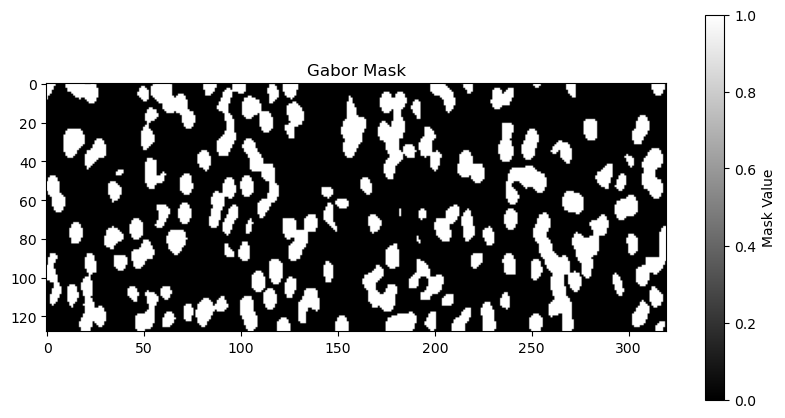

In [47]:
# Plot gabor mask
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.imshow(mask, cmap='gray')
plt.colorbar(label='Mask Value')
plt.title('Gabor Mask')
plt.show()

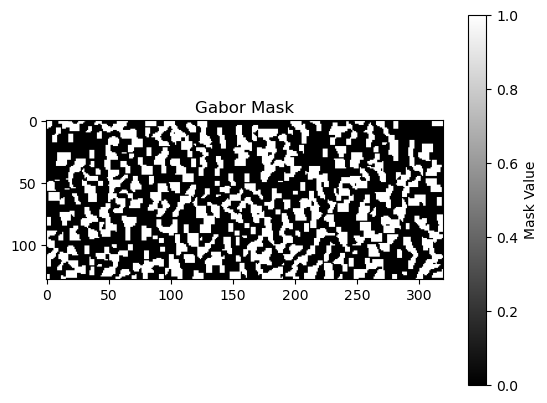

In [48]:
plt.imshow(mask2, cmap='gray')
plt.colorbar(label='Mask Value')
plt.title('Gabor Mask')
plt.show()